In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np 


In [33]:
df=pd.read_csv("C:/Users/USER/Downloads/car_sales_data (1).csv")
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [35]:
df.shape

(50000, 7)

In [36]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


In [37]:


df.isnull().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(12)

<Axes: xlabel='Engine size', ylabel='Count'>

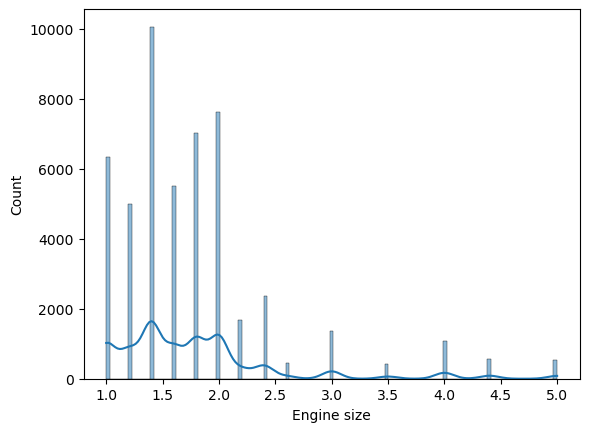

In [39]:
sns.histplot(df['Engine size'], kde=True)  

<Axes: xlabel='Engine size'>

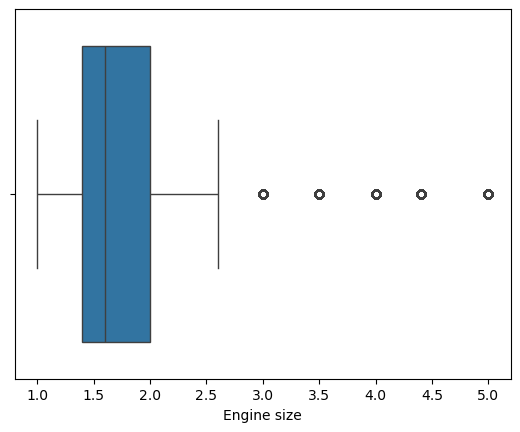

In [40]:
sns.boxplot(x=df['Engine size'])

In [41]:
z_scores=np.abs(stats.zscore(df['Price']))
df[z_scores>3]

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
41,BMW,M5,4.0,Petrol,2017,22759,97758
81,Porsche,718 Cayman,2.4,Petrol,2021,14070,69526
109,Toyota,RAV4,2.4,Petrol,2021,6829,66031
153,Porsche,718 Cayman,4.0,Petrol,2018,20634,70913
167,Toyota,RAV4,1.8,Hybrid,2021,8120,68163
...,...,...,...,...,...,...,...
49833,Porsche,911,3.5,Petrol,2019,18891,126276
49889,BMW,M5,4.4,Petrol,2014,37264,77233
49892,BMW,M5,4.0,Petrol,2018,50096,88934
49938,BMW,M5,4.0,Petrol,2015,47256,74105


In [42]:
Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df[(df['Price']<lower)|(df['Price']>lower)]

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


<Axes: >

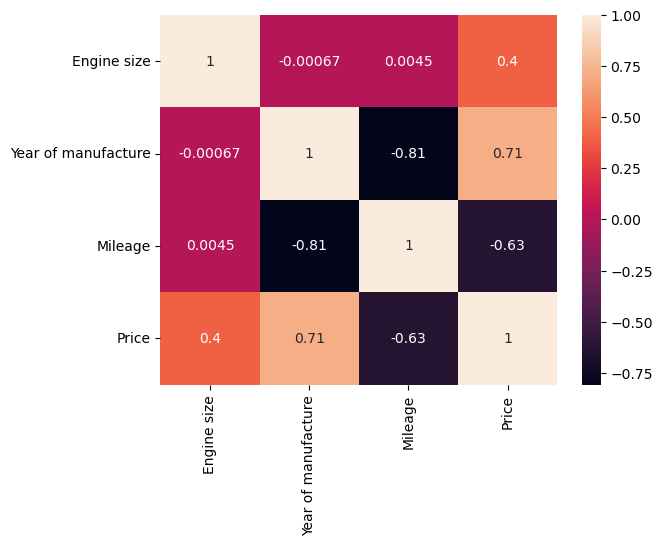

In [43]:
corr = df.corr(numeric_only=True) 
sns.heatmap(corr, annot=True) 

In [44]:
df['Price']=np.where(df['Price']>upper,upper,df['Price'])
df['Price']=np.where(df['Price']<lower,lower,df['Price'])

In [45]:
df['Price']=np.log(df['Price'])

<Axes: xlabel='Engine size', ylabel='Price'>

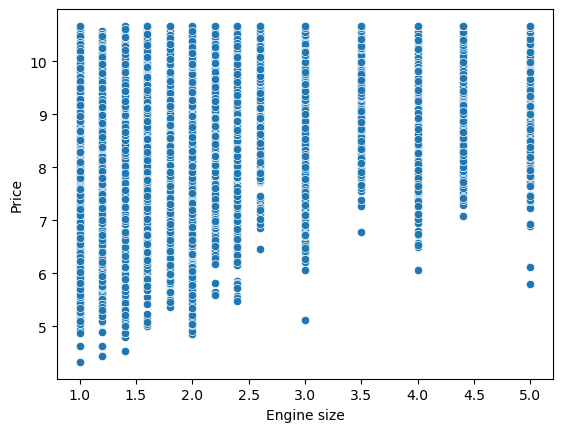

In [46]:
sns.scatterplot(x='Engine size', y='Price', data=df)

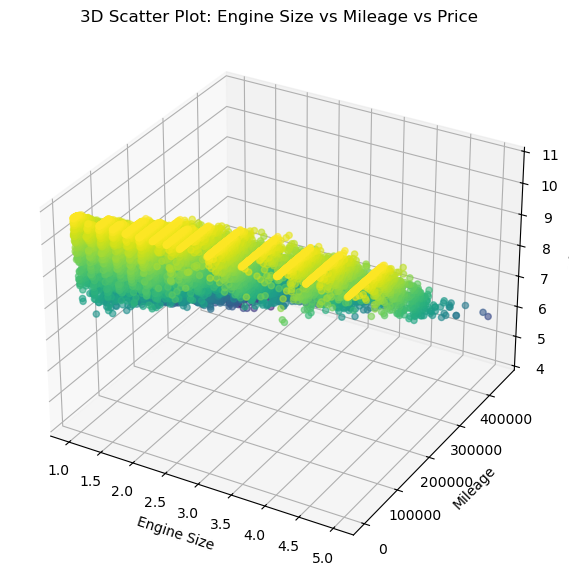

In [27]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    df["Engine size"], 
    df["Mileage"], 
    df["Price"],
    c=df["Price"],        
    cmap="viridis",
    alpha=0.6
)
ax.set_xlabel("Engine Size")
ax.set_ylabel("Mileage")
ax.set_zlabel("Price")
ax.set_title("3D Scatter Plot: Engine Size vs Mileage vs Price")

plt.show()

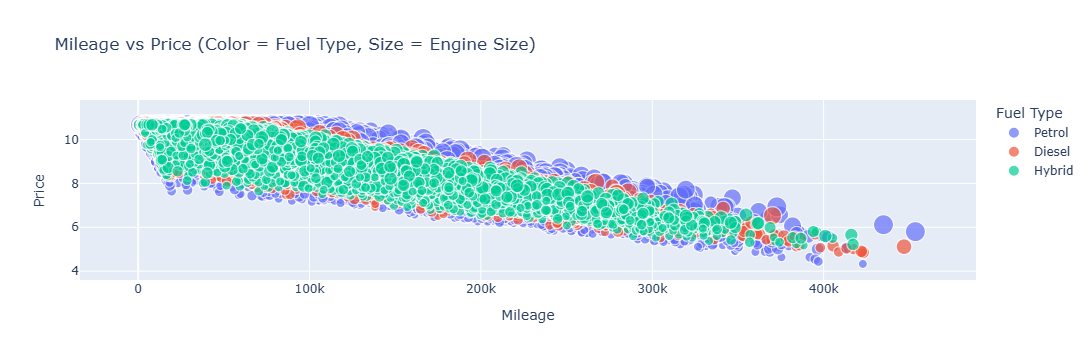

In [29]:
import plotly.express as px
fig = px.scatter(
    df,
    x="Mileage",
    y="Price",
    color="Fuel type",
    size="Engine size",
    hover_name="Manufacturer",
    title="Mileage vs Price (Color = Fuel Type, Size = Engine Size)",
    labels={
        "Mileage": "Mileage",
        "Price": "Price",
        "Fuel type": "Fuel Type",
        "Engine size": "Engine Size"
    }
)

fig.show()